In [2]:
import sys
print(sys.executable)

/Users/siavash/University of Oregon Dropbox/Siavash Jafarizadeh/Python/Github/Nutrition_NLP/.venv/bin/python


In [1]:
import pandas as pd
import numpy as np
import regex as re

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Download NLTK data. Needs to be runned once per session. Can be commented after.
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
# !pip install gensim
from gensim.models import Word2Vec
from collections import Counter
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')


[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/siavash/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/siavash/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/siavash/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Using device: cpu


In [3]:
# If usig colag then set the Colab variable as True. Otherwise, set it as False.

Colab = False

if Colab:
    from google.colab import drive
    drive.mount('/content/drive')

    google_drive = "/content/drive/MyDrive/Colab Notebooks/"    # insert the google drive path to data.

    df_orig = pd.read_parquet(google_drive+'FNDDSeverything.parquet.gzip')
    df = df_orig.select_dtypes(include="object")
else:
    local_drive = ""    # instert the local path to data.

    df_orig = pd.read_parquet(local_drive+'FNDDSeverything.parquet.gzip')
    df = df_orig.select_dtypes(include="object")


Step 1: Processing food descriptions...
Step 2: Creating Word2Vec embeddings...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Step 3: Initializing clusters with KMeans...
Cluster distribution: Counter({9: 22331, 38: 21531, 24: 18700, 12: 17365, 40: 16976, 1: 16172, 16: 15764, 28: 15736, 6: 15645, 20: 14396, 49: 13999, 15: 13441, 22: 13126, 33: 12730, 11: 12278, 36: 12055, 47: 11467, 0: 11128, 2: 10474, 31: 10088, 26: 9522, 35: 9453, 23: 8986, 29: 8823, 8: 8742, 39: 8317, 32: 7942, 27: 7616, 10: 7586, 41: 7559, 4: 7452, 48: 7320, 18: 7313, 17: 6865, 19: 6830, 7: 6255, 46: 6086, 21: 5982, 34: 5852, 3: 5687, 14: 4925, 42: 4682, 45: 4609, 25: 4423, 13: 4342, 30: 4177, 43: 2467, 5: 2268, 37: 1562, 44: 1131})
Step 4: Splitting data...
Step 5: Initializing model...
Step 6: Training model...


Training: 100%|██████████| 751/751 [00:12<00:00, 59.76it/s]


Epoch 1/50
Train Loss: 0.5779, Train Acc: 82.87%
Val Loss: 0.1696, Val Acc: 94.15%
--------------------------------------------------


...

Epoch 48/50
Train Loss: 0.1324, Train Acc: 95.09%
Val Loss: 0.0822, Val Acc: 96.97%
--------------------------------------------------


Training: 100%|██████████| 751/751 [00:09<00:00, 75.78it/s]


Epoch 49/50
Train Loss: 0.1315, Train Acc: 95.13%
Val Loss: 0.0828, Val Acc: 96.95%
--------------------------------------------------


Training: 100%|██████████| 751/751 [00:10<00:00, 71.73it/s]


Epoch 50/50
Train Loss: 0.1307, Train Acc: 95.14%
Val Loss: 0.0845, Val Acc: 96.86%
--------------------------------------------------
Step 7: Getting final predictions...
Final prediction distribution: Counter({9: 22490, 38: 20607, 24: 18449, 12: 17532, 40: 16824, 1: 16377, 28: 15662, 6: 15653, 16: 15506, 20: 14386, 49: 13910, 15: 13591, 22: 12971, 33: 12729, 11: 12211, 36: 12045, 47: 11452, 0: 11298, 2: 10545, 31: 10063, 35: 9614, 26: 9503, 23: 9028, 29: 8872, 8: 8733, 39: 8409, 32: 7922, 10: 7768, 27: 7644, 41: 7592, 4: 7588, 18: 7404, 48: 7380, 17: 6832, 19: 6783, 7: 6319, 46: 6058, 21: 6030, 34: 5881, 3: 5746, 14: 4916, 42: 4687, 45: 4650, 25: 4421, 13: 4367, 30: 4292, 43: 2471, 5: 2290, 37: 1548, 44: 1127})


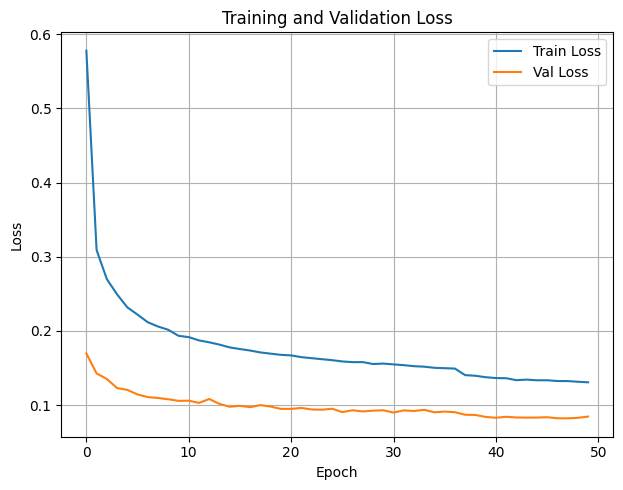


=== Cluster 0 (11298 items) ===
<ArrowStringArray>
[                                           ' JUICE COCKTAIL FROM CONCENTRATE',
                                     ' JUICE COCKTAIL FROM CONCENTRATE, APPLE',
                                  ' ORGANIC BEET + CHERRY JUICE, BEET; CHERRY',
                                 ''TDE PINKY'TUDE RAW CRIPPS PINK APPLE JUICE',
                                        ''TUDE FUJI'TUDE RAW FUJI APPLE JUICE',
                                        ''TUDE GALA'TUDE RAW GALA APPLE JUICE',
                              ''TUDE GRANNY'TUDE RAW GRANNY SMITH APPLE JUICE',
 '+ENERGY VEGETABLE AND FRUIT JUICES FROM CONCENTRATE, POMEGRANATE, BLUEBERRY',
                                             '03 GRAPE FRUIT DRINKING VINEGAR',
                                               '1-DAY DETOX FRUIT JUICE DRINK']
Length: 10, dtype: str

=== Cluster 1 (16377 items) ===
<ArrowStringArray>
[                                   ' AUTHENTIC BARREL RIPENED FETA CHEES

In [4]:
def preprocess_food_entries(text, Tokenize = True):
    """
    Complete preprocessing for food descriptions
    - Removes measurements and numbers
    - Tokenizes
    - Removes stopwords
    - Lemmatizes
    """
    sentence = ''

    # Step 0: Lowercase
    text = text.lower()

    # Step 1: replace ',' with ' '.
    text = re.sub(r',|/', ' ', text)


    # Step 2: Clean special characters but keep spaces
    text = re.sub(r'[^a-z\s]', '', text)

    # Step 3: Remove all measurement patterns
    patterns_to_remove = [
        r'\d+\.?\d*\s?(?:oz|lb|lbs|g|kg|ml|l|cup|cups|tsp|tbsp|pt|qt|gal|mg|mcg|cal|count|ct|pack|pk|piece|pieces|pc|ounce|ounces|pound|pounds|gram|grams|kilogram|kilograms|milliliter|milliliters|liter|liters|teaspoon|teaspoons|tablespoon|tablespoons|pint|pints|quart|quarts|gallon|gallons|milligram|milligrams|microgram|micrograms|calorie|calories|fl|fluid)\b',
        r'\b\d+\.?\d*\b',  # standalone numbers
        r'\d+\.?\d*\s?%',  # percentages
        r'\d+\s?x\s?\d+',  # dimensions
    ]

    for pattern in patterns_to_remove:
        text = re.sub(pattern, '', text, flags=re.IGNORECASE)



    # Step 4: Clean multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 5: Tokenize
    tokens = word_tokenize(text)

    # Step 6: Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [t for t in tokens if t not in stop_words]

    # Step 7: Remove very short tokens
    tokens = [t for t in tokens if len(t) > 2]

    # Step 8: Lemmatize
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    tokens = list(dict.fromkeys(tokens))

    if Tokenize:
        return tokens
    else:
        sentence = " ".join(tokens)
        return sentence

# # Test

# for sample in df.description[[0,24,81,124,134,550,551,552,553]]:
#     tokens = preprocess_food_entries(sample)
#     print(f"Original: {sample}")
#     print(f"Tokens:   {tokens}")
#     sent = preprocess_food_entries(sample, False)
#     print(f"after token sent:   {sent}\n")

# Data Processing Functions

def create_word2vec_embeddings(texts, vector_size=100, window=5, min_count=2, workers=4):
    """
    Creates Word2Vec embeddings from food descriptions.
    Trains a Word2Vec model and returns averaged embeddings for each food item.
    """
    tokenized_texts = [text if isinstance(text, list) else text.split() for text in texts]

    w2v_model = Word2Vec(
        sentences=tokenized_texts,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        workers=workers,
        sg=1,  # Skip-gram model
        epochs=10
    )

    embeddings = []
    for tokens in tokenized_texts:
        word_vectors = [w2v_model.wv[word] for word in tokens if word in w2v_model.wv]
        if word_vectors:
            embeddings.append(np.mean(word_vectors, axis=0))
        else:
            embeddings.append(np.zeros(vector_size))

    return np.array(embeddings), w2v_model


def create_initial_clusters(embeddings, n_clusters=50):
    """
    Creates initial cluster labels using KMeans for semi-supervised learning.
    This provides better initialization than random labels.
    """
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    initial_labels = kmeans.fit_predict(embeddings)
    return initial_labels, kmeans

# Custom PyTorch Dataset

class FoodDataset(Dataset):
    """
    Custom Dataset class for food embeddings and labels.
    Handles conversion to PyTorch tensors and GPU compatibility.
    """
    def __init__(self, embeddings, labels):
        self.embeddings = torch.FloatTensor(embeddings)
        self.labels = torch.LongTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.embeddings[idx], self.labels[idx]

# Neural Network Architecture

class FoodClassifier(nn.Module):
    """
    Deep neural network classifier with multiple hidden layers and batch normalization.
    Architecture designed to prevent mode collapse and single-cluster predictions.
    Uses residual connections and proper initialization for better gradient flow.
    """
    def __init__(self, input_dim, hidden_dims, num_classes, dropout_rate=0.3):
        super(FoodClassifier, self).__init__()

        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = hidden_dim

        self.feature_extractor = nn.Sequential(*layers)
        self.classifier = nn.Linear(prev_dim, num_classes)

        self._initialize_weights()

    def _initialize_weights(self):
        """
        Proper weight initialization to prevent gradient issues.
        Uses Xavier/Glorot initialization for better convergence.
        """
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        features = self.feature_extractor(x)
        output = self.classifier(features)
        return output

# Training Functions

def train_epoch(model, dataloader, criterion, optimizer, device):
    """
    Trains the model for one epoch.
    Returns average loss and accuracy for the epoch.
    """
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for embeddings, labels in tqdm(dataloader, desc="Training"):
        embeddings, labels = embeddings.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(embeddings)
        loss = criterion(outputs, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy


def validate(model, dataloader, criterion, device):
    """
    Validates the model on validation set.
    Returns validation loss and accuracy.
    """
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for embeddings, labels in dataloader:
            embeddings, labels = embeddings.to(device), labels.to(device)
            outputs = model(embeddings)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy


def get_predictions(model, dataloader, device):
    """
    Gets predictions for entire dataset.
    Returns predicted cluster labels.
    """
    model.eval()
    predictions = []

    with torch.no_grad():
        for embeddings, _ in dataloader:
            embeddings = embeddings.to(device)
            outputs = model(embeddings)
            _, predicted = torch.max(outputs.data, 1)
            predictions.extend(predicted.cpu().numpy())

    return np.array(predictions)

# Main Training Pipeline

def train_food_classifier(D, num_clusters=50, embedding_dim=100, epochs=50, batch_size=512, learning_rate=0.001):
    """
    Main training pipeline that orchestrates the entire process:
    1. Processes food descriptions using your clean_food_entrie function
    2. Creates Word2Vec embeddings
    3. Initializes clusters
    4. Trains neural network classifier
    5. Returns trained model and predictions
    """

    print("Step 1: Processing food descriptions...")
    processed_texts = [preprocess_food_entries(text, True) for text in D]

    print("Step 2: Creating Word2Vec embeddings...")
    embeddings, w2v_model = create_word2vec_embeddings(
        processed_texts,
        vector_size=embedding_dim
    )

    print("Step 3: Initializing clusters with KMeans...")
    initial_labels, kmeans = create_initial_clusters(embeddings, n_clusters=num_clusters)

    print(f"Cluster distribution: {Counter(initial_labels)}")

    print("Step 4: Splitting data...")
    X_train, X_val, y_train, y_val = train_test_split(
        embeddings, initial_labels, test_size=0.2, random_state=42, stratify=initial_labels
    )

    train_dataset = FoodDataset(X_train, y_train)
    val_dataset = FoodDataset(X_val, y_val)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0) # changed num_workers to 0 
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    print("Step 5: Initializing model...")
    model = FoodClassifier(
        input_dim=embedding_dim,
        hidden_dims=[512, 256, 128],
        num_classes=num_clusters,
        dropout_rate=0.3
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

    print("Step 6: Training model...")
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_loss = float('inf')

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        scheduler.step(val_loss)

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        print("-" * 50)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_food_classifier.pth')

    print("Step 7: Getting final predictions...")
    model.load_state_dict(torch.load('best_food_classifier.pth'))
    full_dataset = FoodDataset(embeddings, initial_labels)
    full_loader = DataLoader(full_dataset, batch_size=batch_size, shuffle=False)
    final_predictions = get_predictions(model, full_loader, device)

    print(f"Final prediction distribution: {Counter(final_predictions)}")

    return model, final_predictions, w2v_model, embeddings, train_losses, val_losses

# Visualization Functions

def plot_training_history(train_losses, val_losses):
    """
    Plots training and validation loss curves to monitor convergence.
    """
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig('training_history.png')
    plt.show()


def analyze_clusters(D, predictions, top_n=10):
    """
    Analyzes and displays top words for each cluster.
    Helps interpret what each cluster represents.
    """
    D_with_clusters = D.copy()
    D_with_clusters['cluster'] = predictions

    for cluster_id in range(predictions.max() + 1):
        cluster_foods = D_with_clusters[D_with_clusters['cluster'] == cluster_id]
        print(f"\n=== Cluster {cluster_id} ({len(cluster_foods)} items) ===")
        print(cluster_foods['description'].head(top_n).values)

def clusters_stats(D, predictions, top_n=5):
    """
    Analyzes and displays top categories for each cluster.
    Helps interpret what each cluster represents.
    """
    D_with_clusters = D.copy()
    D_with_clusters['cluster'] = predictions

    # Graph the length of each cluster in a histogram
    cluster_sizes = [len(D_with_clusters[D_with_clusters['cluster'] == cluster_id]) for cluster_id in range(predictions.max() + 1)]
    plt.figure(figsize=(10, 6))
    plt.hist(cluster_sizes, bins=range(min(cluster_sizes), max(cluster_sizes) + 2), edgecolor='black', alpha=0.7)
    plt.xlabel('Cluster Size')
    plt.ylabel('Number of Clusters')
    plt.title('Histogram of Cluster Sizes')
    plt.grid(True)
    plt.show()

    for cluster_id in range(predictions.max() + 1):
        cluster_class = D_with_clusters[D_with_clusters['cluster'] == cluster_id]
        print(f"\n=== Cluster {cluster_id} ({len(cluster_class)} items) ===")
        # Print the count of 'category' column for each entry in the cluster
        category_counts = cluster_class['category'].value_counts()
        print("Category counts:")
        print(category_counts)
        print(cluster_class['description'].head(top_n).values)

# Example Usage
# D = [preprocess_food_entries(f"{desc} {cat}", False)
#      for desc, cat in zip(df['description'], df['category'])]

D = [preprocess_food_entries(f"{desc}", False)
     for desc in df['description']]

# Train the model
model, predictions, w2v_model, embeddings, train_losses, val_losses = train_food_classifier(
    D=D,
    num_clusters=50,
    embedding_dim=100,
    epochs=50,
    batch_size=512,
    learning_rate=0.001
)

# Plot training history
plot_training_history(train_losses, val_losses)

# Analyze clusters
# Note: D here is a list, not a DataFrame. For analyze_clusters to work, D needs to be the original df or a DataFrame with a 'description' column.
# Assuming the intent is to analyze the original dataframe with predictions, the line D_with_clusters = D.copy() might fail if D is a list.
# If the original dataframe 'df' is to be used for analysis, it should be passed instead of the list 'D'.
# For now, let's assume 'D' in analyze_clusters is meant to be the original 'df'.
# Or, if D is meant to be the list of preprocessed strings, analyze_clusters needs to be adapted.
# For the immediate error, the previous fix is sufficient. Re-evaluating the analyze_clusters call might be needed later.
analyze_clusters(df, predictions, top_n=10) # Using original 'df' for analysis

# Save results
# df['predicted_cluster'] = predictions # Assigning to df, not D
# df.to_csv('food_data_with_clusters.csv', index=False)


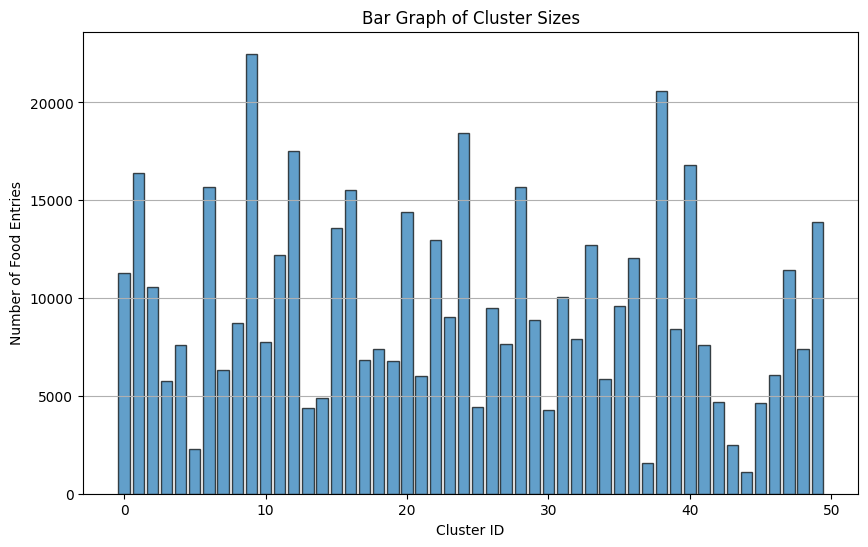


=== Cluster 0 (11298 items) ===
Category counts:
category
Fruit & Vegetable Juice, Nectars & Fruit Drinks    7441
Canned Fruit                                        905
Other Drinks                                        499
Frozen Fruit & Fruit Juice Concentrates             432
Soda                                                402
Name: count, dtype: int64

=== Cluster 1 (16377 items) ===
Category counts:
category
Cheese                                6872
Frozen Appetizers & Hors D'oeuvres    1163
Pasta Dinners                          837
Other Snacks                           686
Frozen Dinners & Entrees               581
Name: count, dtype: int64

=== Cluster 2 (10545 items) ===
Category counts:
category
Cakes, Cupcakes, Snack Cakes             5649
Baking Decorations & Dessert Toppings    1401
Cake, Cookie & Cupcake Mixes             1181
Cookies & Biscuits                        356
Baking/Cooking Mixes/Supplies             237
Name: count, dtype: int64

=== Cluster 3 (5746

In [8]:
def clusters_stats(D, predictions, top_n=5):
    """
    Analyzes and displays top categories for each cluster.
    Helps interpret what each cluster represents.
    """
    D_with_clusters = D.copy()
    D_with_clusters['cluster'] = predictions

    # Graph the length of each cluster in a bar graph
    cluster_sizes = [len(D_with_clusters[D_with_clusters['cluster'] == cluster_id]) for cluster_id in range(predictions.max() + 1)]
    cluster_ids = list(range(predictions.max() + 1))
    plt.figure(figsize=(10, 6))
    plt.bar(cluster_ids, cluster_sizes, edgecolor='black', alpha=0.7)
    plt.xlabel('Cluster ID')
    plt.ylabel('Number of Food Entries')
    plt.title('Bar Graph of Cluster Sizes')
    plt.grid(True, axis='y')
    plt.show()

    for cluster_id in range(predictions.max() + 1):
        cluster_class = D_with_clusters[D_with_clusters['cluster'] == cluster_id]
        print(f"\n=== Cluster {cluster_id} ({len(cluster_class)} items) ===")
        print("Category counts:")
        # Print the count of 'category' column for each entry in the cluster
        category_counts = cluster_class['category'].value_counts().head(top_n)
        print(category_counts)


clusters_stats(df, predictions, top_n=5)

In [ ]:
# what are the 5 most common USDA-supplied categories in each cluster?
for c in range(18):
  print(f'\nCluster {c}\n')
  print(df.loc[df['k18'] == c, 'category'].value_counts().head(5))

In [1]:
import numpy
print(numpy.__version__)
import torch
print(torch.__version__)

1.26.4
2.2.2


In [ ]:
D = [preprocess_food_entries(f"{desc} {cat}", False)
     for desc, cat in zip(df['description'], df['category'])]